# IMPORTS

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st 
import seaborn as sns

## CARGAR LOS DATOS

In [2]:
#cargamos el ata set cambiando los nombres de las columnas a minusculas 
data_games_2016 = pd.read_csv('/datasets/games.csv')
data_games_2016.columns = data_games_2016.columns.str.lower()
data_games_2016.info()
data_games_2016.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


## PREPARACION DE LOS DATOS

In [3]:
#convertimos los datos en los tipos nececsarios
data_games_2016['year_of_release'] = data_games_2016['year_of_release'].astype('Int64')
data_games_2016['user_score'] = pd.to_numeric(data_games_2016['user_score'], errors='coerce')
data_games_2016.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.4+ MB


* Cambiamos los tipos de datos en la columna 'year of release' para tener una mejor coeherencia en los datospasandola de (float) a (int), ya que esta columna nos habla del año en que se lanso el juego
* tambien cambiamos la columna 'user score' a un tipo de dato numerico ya que era de tipo (obgect), para tener un analisis mas exsacto en futuros calculos ya que este nos habla del score que le da cada usuario al juego
* Manejo de "TBD": Significa "To Be Determined". En términos de análisis,trataremos estos como valores ausentes, Los valores pueden faltar por errores en la recopilación, porque el juego es muy antiguo y no hay registros digitales, o porque simplemente no fueron calificados.
* Rellenar valores ausetes user_score y critic stroe : Para este analisis, lo más equilibrado es agrupar por género y rellenar con la mediana, ya que la mediana es más resistente a los valores atípicos,
* Rellenar valores ausentes rating : Para este analisis,no necitamos rellenar los valores ausentes ,para la proyeccion de 2017 mas adelante buscaremos los juegos que no tienen rating analisando similitudes para poder rellenar los datos ausentes

In [4]:
#rellenamos los valores ausentes en critic_score y user_score con la media de cada grupro  
data_games_2016['critic_score'] = data_games_2016['critic_score'].fillna(data_games_2016.groupby('genre')['critic_score'].transform('mean'))
data_games_2016['user_score'] = data_games_2016['user_score'].fillna(data_games_2016.groupby('genre')['user_score'].transform('mean'))
data_games_2016['critic_score'] = data_games_2016['critic_score'].round(1)
data_games_2016['user_score'] = data_games_2016['user_score'].round(1)
data_games_2016.info()
data_games_2016.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     16713 non-null  float64
 9   user_score       16713 non-null  float64
 10  rating           9949 non-null   object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.4+ MB


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,68.1,7.3,NaN
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,72.7,7.6,NaN
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,67.4,7.2,NaN
6,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,70.2,7.0,NaN


* En la columna year of release no podemos rellenar los valores ausentes si no conosemos el año de lanzamiento del jueg
* las columnas critic score y user score redondeamos las calificaciones a un decimal ya que en la realidad de las calificaciones de los juegos solo se califica con un decimal y asi podemos evitar una falsa presicion 

In [5]:
#calculamos las ventas totales y creamos una nueva columna en el df
data_games_2016['total_sales'] = data_games_2016[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1)
data_games_2016.head(10)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,68.1,7.3,NaN,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,72.7,7.6,NaN,31.38
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,67.4,7.2,NaN,30.26
6,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E,29.80
7,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E,28.91
8,New Super Mario Bros. Wii,Wii,2009,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E,28.32
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,70.2,7.0,NaN,28.31


# ANALISIS DE LOS DATOS 

In [6]:
#analisis de juegos lansados por año
games_per_year = data_games_2016.groupby('year_of_release')['name'].count()
print(games_per_year)

year_of_release
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: name, dtype: int64


## JUEGOS LANZADOS EN DIFERENTES AÑOS

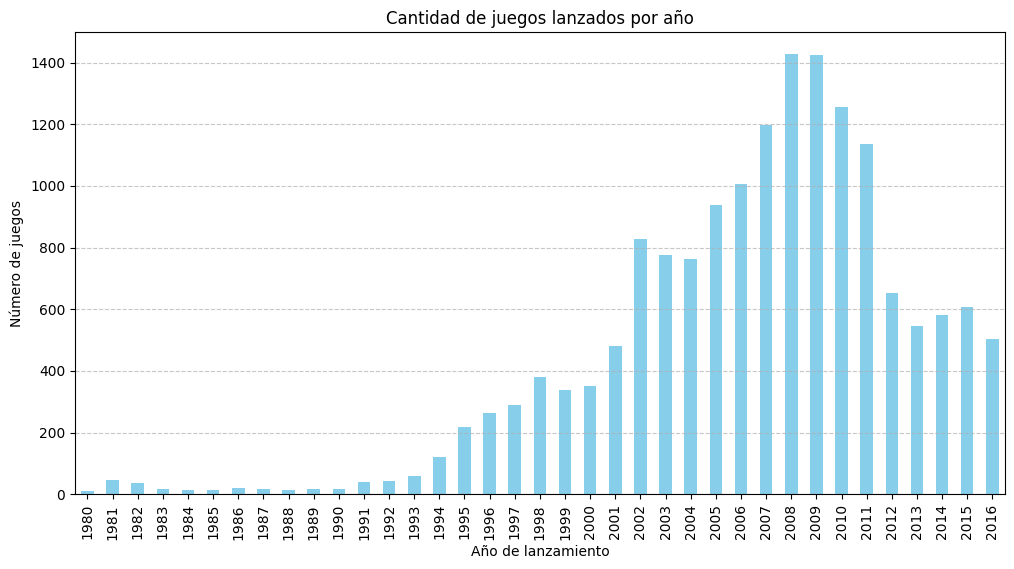

In [7]:
#grafica de el lansamiento de juegos por año
games_per_year.plot(kind='bar', figsize=(12, 6), color='skyblue')
plt.title('Cantidad de juegos lanzados por año')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Número de juegos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

* Antes de 1994-1995: Hay muy pocos lanzamientos. La industria era pequeña y los datos pueden no ser representativos para las tendencias actuales.
* El "Boom" (2002-2011): Vemos un crecimiento masivo de lanzamientos.
 
* ¿Son significativos los datos de todos los periodos?
 Probablemente no. Para predecir el éxito en 2017, los datos de los años 80 tienen un comportamiento de mercado totalmente distinto   al actual. Suele ser mejor enfocarse en los últimos años (por ejemplo, de 2012 en adelante).

In [8]:
#sumamos las ventas totales de las plataformas para obtener el top 10
platforms_sales = data_games_2016.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
top10_platforms_sales= platforms_sales.head(10)
print(top10_platforms_sales)
print(platforms_sales)

platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
Name: total_sales, dtype: float64
platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
3DS      259.00
XB       257.74
GB       255.46
NES      251.05
N64      218.68
SNES     200.04
GC       198.93
XOne     159.32
2600      96.98
WiiU      82.19
PSV       54.07
SAT       33.59
GEN       30.77
DC        15.95
SCD        1.86
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: total_sales, dtype: float64


## DISTRIBUSION DE VENTAS POR AÑO 

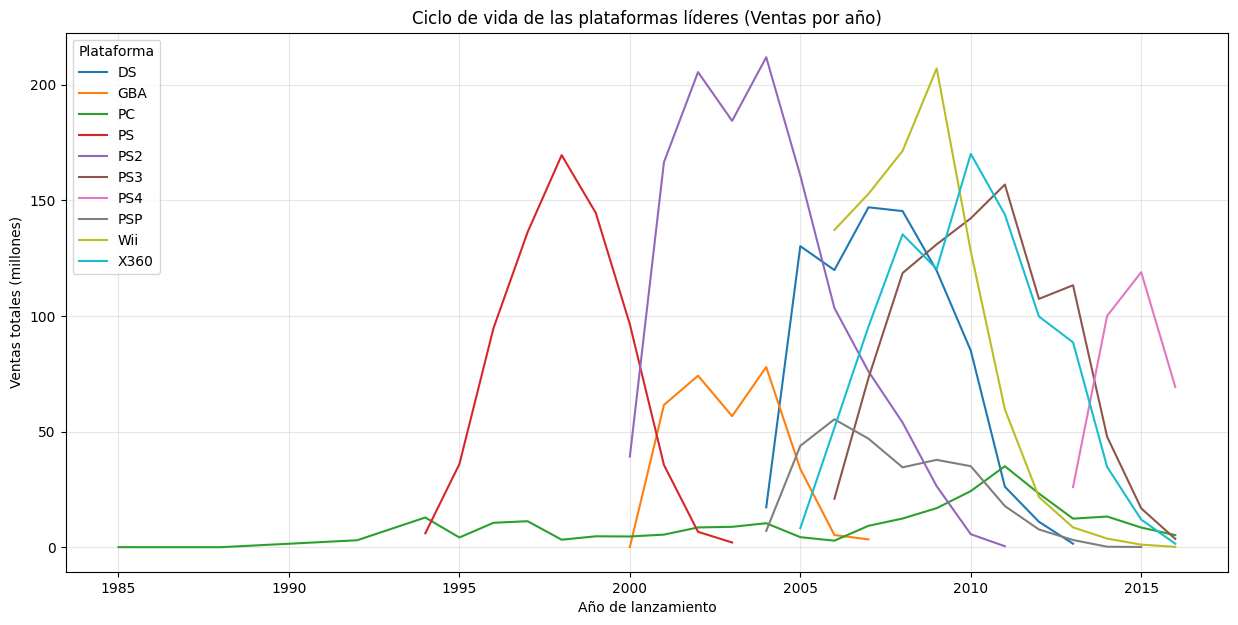

In [9]:
#grafica de la distribucion de ventas y ciclo de vida del top 10  de plataformas 
data_games_2016.query('platform in @top10_platforms_sales.index').pivot_table(
    index='year_of_release', 
    columns='platform', 
    values='total_sales', 
    aggfunc='sum').plot(figsize=(15, 7))

plt.title('Ciclo de vida de las plataformas líderes (Ventas por año)')
plt.ylabel('Ventas totales (millones)')
plt.xlabel('Año de lanzamiento')
plt.legend(title='Plataforma')
plt.grid(alpha=0.3)
plt.show()

* El ciclo de vida de una consola (cuándo nace, cuándo llega a su pico y cuándo muere).
* Vida promedio: la mayoría de las consolas (como PS2, Wii o Xbox 360) tienen un ciclo de vida de unos 10 años aproximadamente.
* El Pico: Suelen alcanzar su punto máximo de ventas a los 4 o 5 años de haber salido al mercado.
* Transición: Verás que cuando una plataforma empieza a caer (ej. PS3), la siguiente generación (ej. PS4) empieza a subir rápidamente.
Para preparar el pronóstico de
2017, lo más profesional es trabajar con un "período relevante". Usar datos de 1990 no sirve porque el mercado era distinto. Un estándar en la industria es usar los últimos 3 o 4 años.

## DETERMINAMOS LOS DATOS PARA LA PROYECCION 

In [10]:
#determinamos los datos relevantes para la proyeccion (utilizando los ultimos 5 años)
data_games_relevant = data_games_2016[data_games_2016['year_of_release'] >= 2013].copy()
data_games_relevant.info()

data_games_relevant.head(10)


<class 'pandas.core.frame.DataFrame'>
Int64Index: 2233 entries, 16 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             2233 non-null   object 
 1   platform         2233 non-null   object 
 2   year_of_release  2233 non-null   Int64  
 3   genre            2233 non-null   object 
 4   na_sales         2233 non-null   float64
 5   eu_sales         2233 non-null   float64
 6   jp_sales         2233 non-null   float64
 7   other_sales      2233 non-null   float64
 8   critic_score     2233 non-null   float64
 9   user_score       2233 non-null   float64
 10  rating           1256 non-null   object 
 11  total_sales      2233 non-null   float64
dtypes: Int64(1), float64(7), object(4)
memory usage: 229.0+ KB


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,70.2,7.0,NaN,14.63
33,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,72.7,7.6,NaN,14.60
42,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62
47,Pokemon Omega Ruby/Pokemon Alpha Sapphire,3DS,2014,Role-Playing,4.35,3.49,3.10,0.74,72.7,7.6,NaN,11.68
60,Call of Duty: Ghosts,X360,2013,Shooter,6.73,2.56,0.04,0.91,73.0,2.6,M,10.24
69,Call of Duty: Ghosts,PS3,2013,Shooter,4.10,3.63,0.38,1.25,71.0,2.6,M,9.36
72,Minecraft,X360,2013,Misc,5.70,2.65,0.02,0.81,66.6,6.8,NaN,9.18
77,FIFA 16,PS4,2015,Sports,1.12,6.12,0.06,1.28,82.0,4.3,E,8.58


In [11]:
# Creamos un diccionario con el rating conocido para cada nombre de juego
mapeo_name_rating = data_games_relevant.dropna(subset=['rating']).set_index('name')['rating'].to_dict()
# Aplicamos ese mapeo a las filas donde el rating es nulo
data_games_relevant['rating'] = data_games_relevant['rating'].fillna(data_games_relevant['name'].map(mapeo_name_rating))

data_games_relevant.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2233 entries, 16 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             2233 non-null   object 
 1   platform         2233 non-null   object 
 2   year_of_release  2233 non-null   Int64  
 3   genre            2233 non-null   object 
 4   na_sales         2233 non-null   float64
 5   eu_sales         2233 non-null   float64
 6   jp_sales         2233 non-null   float64
 7   other_sales      2233 non-null   float64
 8   critic_score     2233 non-null   float64
 9   user_score       2233 non-null   float64
 10  rating           1333 non-null   object 
 11  total_sales      2233 non-null   float64
dtypes: Int64(1), float64(7), object(4)
memory usage: 229.0+ KB


In [12]:
# Rellenamos usando la moda de la combinación Género + Plataforma
data_games_relevant['rating'] = data_games_relevant.groupby(['genre', 'platform'])['rating'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan))
data_games_relevant.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2233 entries, 16 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             2233 non-null   object 
 1   platform         2233 non-null   object 
 2   year_of_release  2233 non-null   Int64  
 3   genre            2233 non-null   object 
 4   na_sales         2233 non-null   float64
 5   eu_sales         2233 non-null   float64
 6   jp_sales         2233 non-null   float64
 7   other_sales      2233 non-null   float64
 8   critic_score     2233 non-null   float64
 9   user_score       2233 non-null   float64
 10  rating           2181 non-null   object 
 11  total_sales      2233 non-null   float64
dtypes: Int64(1), float64(7), object(4)
memory usage: 229.0+ KB


In [13]:
# Rellenamos usando el valor uknown para los valores unicos en generos poco comunes
data_games_relevant['rating'] = data_games_relevant['rating'].fillna('Unknown')
data_games_relevant.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2233 entries, 16 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             2233 non-null   object 
 1   platform         2233 non-null   object 
 2   year_of_release  2233 non-null   Int64  
 3   genre            2233 non-null   object 
 4   na_sales         2233 non-null   float64
 5   eu_sales         2233 non-null   float64
 6   jp_sales         2233 non-null   float64
 7   other_sales      2233 non-null   float64
 8   critic_score     2233 non-null   float64
 9   user_score       2233 non-null   float64
 10  rating           2233 non-null   object 
 11  total_sales      2233 non-null   float64
dtypes: Int64(1), float64(7), object(4)
memory usage: 229.0+ KB


* Para una mayor precisión al rellenar los valores ausentes de rating 
  buscamos el rating del juego en otras plataformas primero y, solo si no existe en ninguna,
  podemos usar un valor estadístico basado en criterios más estrechos.
* Rellenar por el mismo juego en otras plataformas, Si en otra plataforma encontramos el mismo juego,
  lo lógico es copiar ese mismo valor.
* Rellenar por "Género + Plataforma":
  En lugar de usar el género de forma global, es mejor usar la moda del género dentro de la misma plataforma. Por ejemplo, los         juegos de "Shooter" en PC pueden tener una tendencia de rating distinta a los de una consola de Nintendo.
* Despues de rellenar los datos ausentes de las maneras anteriores encontramos que aun hay valores nulos esto podria ser porque son    juegos unicos en generos poco comunes los consideraremos en una categoria nueva determinada uknouwn para no sesgar pruebas de      hipotesis futuras    
  

## PLATAFORMAS LIDERES EN VENTAS 

In [14]:
# sumamos las ventas totales por plataforma paraobtener el top en ventas 
recent_top = data_games_relevant.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print(recent_top)

platform
PS4     314.14
PS3     181.43
XOne    159.32
3DS     143.25
X360    136.80
WiiU     64.63
PC       39.43
PSV      32.99
Wii      13.66
PSP       3.50
DS        1.54
Name: total_sales, dtype: float64


In [17]:

# Calculamos la varianza
varianza_ventas = recent_top.var()

# Calculamos la desviación estándar
desviacion_estandar_ventas = recent_top.std()

print(f"Varianza de las ventas totales: {varianza_ventas:.2f}")
print(f"Desviación estándar de las ventas totales: {desviacion_estandar_ventas:.2f}")


Varianza de las ventas totales: 9509.39
Desviación estándar de las ventas totales: 97.52


La Varianza: nos dice tan dispersos están los datos respecto al promedio. Al ser ventas de consolas de distintas generaciones, este número será muy alto porque hay mucha diferencia entre los líderes y los últimos lugares.

Desviación estándar de 97.52 indica una gran dispersión en las ventas entre plataformas

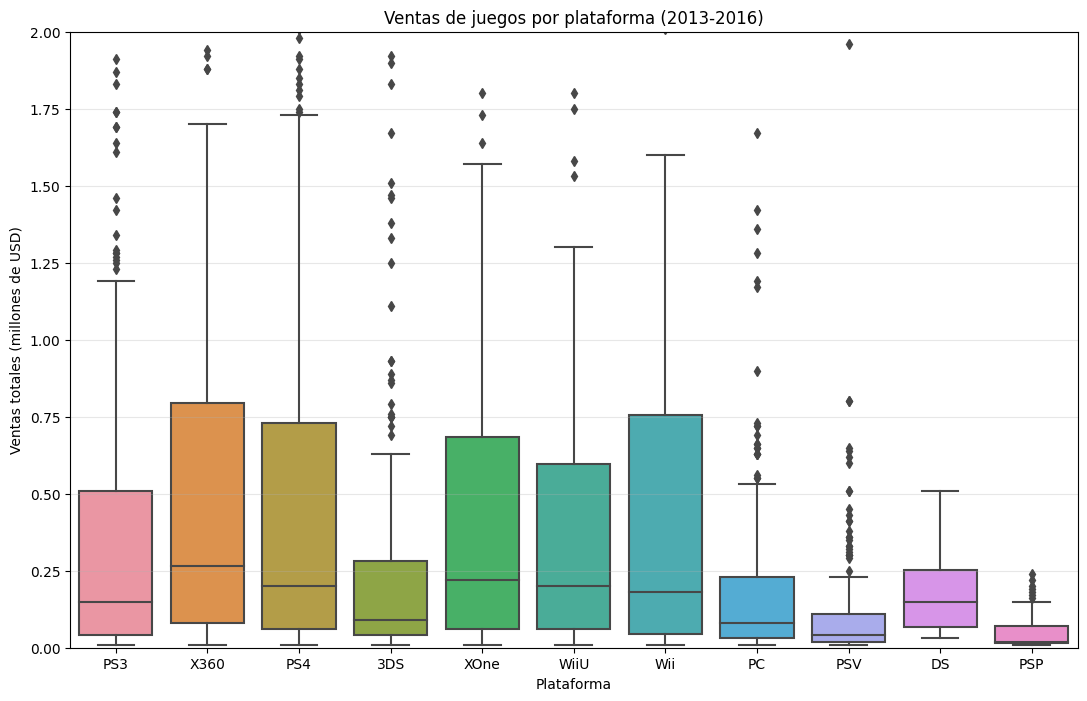

In [19]:
#grafico de caja de venta de juegos por plataforma 
plt.figure(figsize=(13, 8))
sns.boxplot(data=data_games_relevant, x='platform', y='total_sales')

plt.title('Ventas de juegos por plataforma (2013-2016)')
plt.xlabel('Plataforma')
plt.ylabel('Ventas totales (millones de USD)')
plt.ylim(0, 2) # Limitamos el eje Y para ver mejor las cajas, ya que hay éxitos de 20M que "aplastan" el gráfico
plt.grid(axis='y', alpha=0.3)
plt.show()

1. PS4 y Xbox One: Las sucesoras en ascenso
Aunque en el gráfico las cajas de PS3 y X360 parecen "más grandes" (tienen una mediana y un tercer cuartil más altos),  ese gráfico suma todo el periodo 2013-2016.
En donde  PS4 y Xbox One son consolas de nueva generación. Sus ventas están en su pico de crecimiento porque los desarrolladores están abandonando las consolas viejas para enfocarse en estas.
* Ventas Promedio:  la caja de PS4 es bastante sólida y tiene muchos puntos (outliers) por encima de 1.75 millones.
Esto indica que es la plataforma donde los grandes éxitos (AAA) venden mejor actualmente.
2. PC: Estabilidad y nicho
la caja de la PC en el gráfico: es pequeña y está situada muy abajo.
Esto no significa que la PC sea mala, sino que tiene muchísimos juegos que venden poco (mercado indie), pero se mantiene constante año tras año. A diferencia de las consolas, no "muere" cuando sale una nueva, por lo que es una apuesta segura y rentable a largo plazo.
3. 3DS: Resistencia en portátiles
La caja de la 3DS es compacta y tiene una mediana baja, pero posee muchísimos valores atípicos (puntos negros).
Esto demuestra que, aunque un juego promedio de 3DS no vende millones, sus franquicias exclusivas (como Pokémon o Mario) son éxitos masivos. Sin embargo, al ser una consola de 2011, para 2017 su tecnología ya es considerada antigua.
5. PS3 y Xbox 360: El fin de una era
Aunque sus cajas en el acumulado 2013-2016 se ven bien, si hiciéramos este mismo gráfico solo para el año 2016, verías que casi han desaparecido.
Los usuarios ya migraron. En 2017, lanzar un juego para estas plataformas es arriesgado porque la base de jugadores activos que compran novedades es mínima.
* Conclusión
Para 2017, las plataformas con mayor potencial de ventas son PS4 y Xbox One debido a su ciclo de vida ascendente, seguidas por PC por su estabilidad. Las demás están en una fase de contracción o desaparición del mercado.


## CORRELACION ENTRE RESEÑAS Y VENTAS 

In [20]:
#extraemos los datos entre ventas y reseñas de ps4 del data frame 
ps4_data = data_games_relevant[(data_games_relevant['platform'] == 'PS4') & 
                     (data_games_relevant['critic_score']) & 
                     (data_games_relevant['user_score'])]
ps4_data.head(10)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,70.2,7.0,M,14.63
42,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62
77,FIFA 16,PS4,2015,Sports,1.12,6.12,0.06,1.28,82.0,4.3,E,8.58
87,Star Wars Battlefront (2015),PS4,2015,Shooter,2.99,3.49,0.22,1.28,70.2,7.0,M,7.98
92,Call of Duty: Advanced Warfare,PS4,2014,Shooter,2.81,3.48,0.14,1.23,83.0,5.7,M,7.66
94,FIFA 17,PS4,2016,Sports,0.66,5.75,0.08,1.11,85.0,5.0,E,7.60
105,Fallout 4,PS4,2015,Role-Playing,2.53,3.27,0.24,1.13,87.0,6.5,M,7.17
143,FIFA 15,PS4,2014,Sports,0.80,4.33,0.05,0.90,82.0,5.7,E,6.08
154,Destiny,PS4,2014,Shooter,2.49,2.07,0.16,0.92,76.0,6.1,T,5.64
171,Uncharted 4: A Thief's End,PS4,2016,Shooter,1.85,2.50,0.19,0.85,93.0,7.9,T,5.39


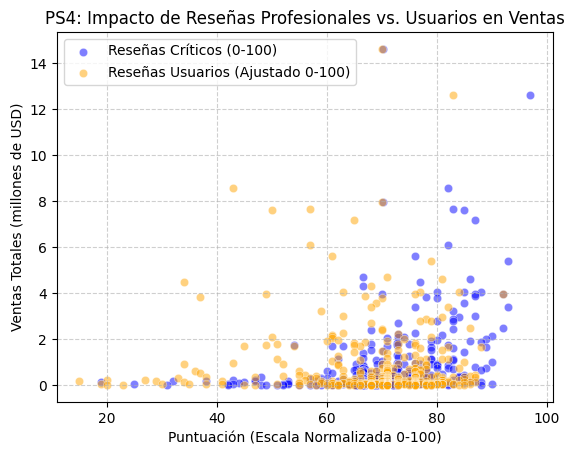

In [21]:
#grafico de dispercion entre ventas y reseñas ps4
sns.scatterplot(data=ps4_data, x='critic_score', y='total_sales', 
                alpha=0.5, color='blue', label='Reseñas Críticos (0-100)')
sns.scatterplot(x=ps4_data['user_score'] * 10, y=ps4_data['total_sales'], 
                alpha=0.5, color='orange', label='Reseñas Usuarios (Ajustado 0-100)')

plt.title('PS4: Impacto de Reseñas Profesionales vs. Usuarios en Ventas')
plt.xlabel('Puntuación (Escala Normalizada 0-100)')
plt.ylabel('Ventas Totales (millones de USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [22]:
#obtenemos la correlacion entre ventas y reseñas 
cor_critic = ps4_data['critic_score'].corr(ps4_data['total_sales'])
cor_user = ps4_data['user_score'].corr(ps4_data['total_sales'])

print(f"Correlación Ventas - Críticos: {cor_critic:.2f}")
print(f"Correlación Ventas - Usuarios: {cor_user:.2f}")

Correlación Ventas - Críticos: 0.35
Correlación Ventas - Usuarios: -0.05


Conclusiones del Análisis
* Influencia de los Profesionales (0.35): Existe una correlación positiva moderada.
  Esto indica que las buenas calificaciones de la prensa especializada suelen acompañar a los juegos con mayores ventas.
  Es un factor de confianza importante para el comprador de PS4.
* influencia del Usuario (-0.03): La correlación es prácticamente nula.
  Esto significa que las notas de los jugadores no predicen el éxito comercial.
   Un juego puede tener una calificación de usuario muy baja (por quejas técnicas o polémicas) y aun así ser un éxito masivo en ventas.
* Tendencia Visual: En el gráfico notamos que los juegos que superan los 4 millones de ventas (los "hits") se concentran casi siempre en puntuaciones de críticos superiores    a 80, mientras que en las notas de usuarios los éxitos están esparcidos por toda la gráfica.

* Para la plataforma PS4, las reseñas profesionales tienen mucho más peso en el desempeño comercial que la opinión pública de los usuarios.

## VENTAS MISMOS JUEGOS EN OTRAS PLATAFORMAS 

In [23]:
#estraemos los juegos que se encuentras en las mismas plataformas  
juegos_comunes = data_games_relevant[data_games_relevant['platform'].isin(['PS4', 'XOne', 'PC'])]
juegos_en_todas = juegos_comunes.groupby('name').filter(lambda x: x['platform'].nunique() == 3)


In [24]:
#muestra todos los juegos en las mismas plataformas 
juegos_en_todas['name'].unique()

array(['Call of Duty: Black Ops 3', 'Grand Theft Auto V', 'FIFA 16',
       'Star Wars Battlefront (2015)', 'Call of Duty: Advanced Warfare',
       'FIFA 17', 'Fallout 4', 'FIFA 15',
       'Call of Duty: Infinite Warfare', 'Battlefield 1', 'Watch Dogs',
       'Far Cry 4', 'The Witcher 3: Wild Hunt', "Assassin's Creed: Unity",
       'Batman: Arkham Knight', 'NBA 2K16', 'Call of Duty: Ghosts',
       "Tom Clancy's The Division", 'Battlefield 4',
       'Metal Gear Solid V: The Phantom Pain',
       "Assassin's Creed Syndicate", 'FIFA 14',
       'Middle-Earth: Shadow of Mordor',
       "Assassin's Creed IV: Black Flag", 'Mortal Kombat X',
       'Need for Speed (2015)', 'Far Cry: Primal',
       "Tom Clancy's Rainbow Six: Siege", 'Overwatch',
       'Battlefield: Hardline', 'Dying Light', 'Dragon Age: Inquisition',
       'Need for Speed Rivals', 'NBA 2K17', 'Just Cause 3', 'Mafia III',
       'The Evil Within', 'The Elder Scrolls Online', 'The Crew',
       'Dark Souls III', 'LEGO M

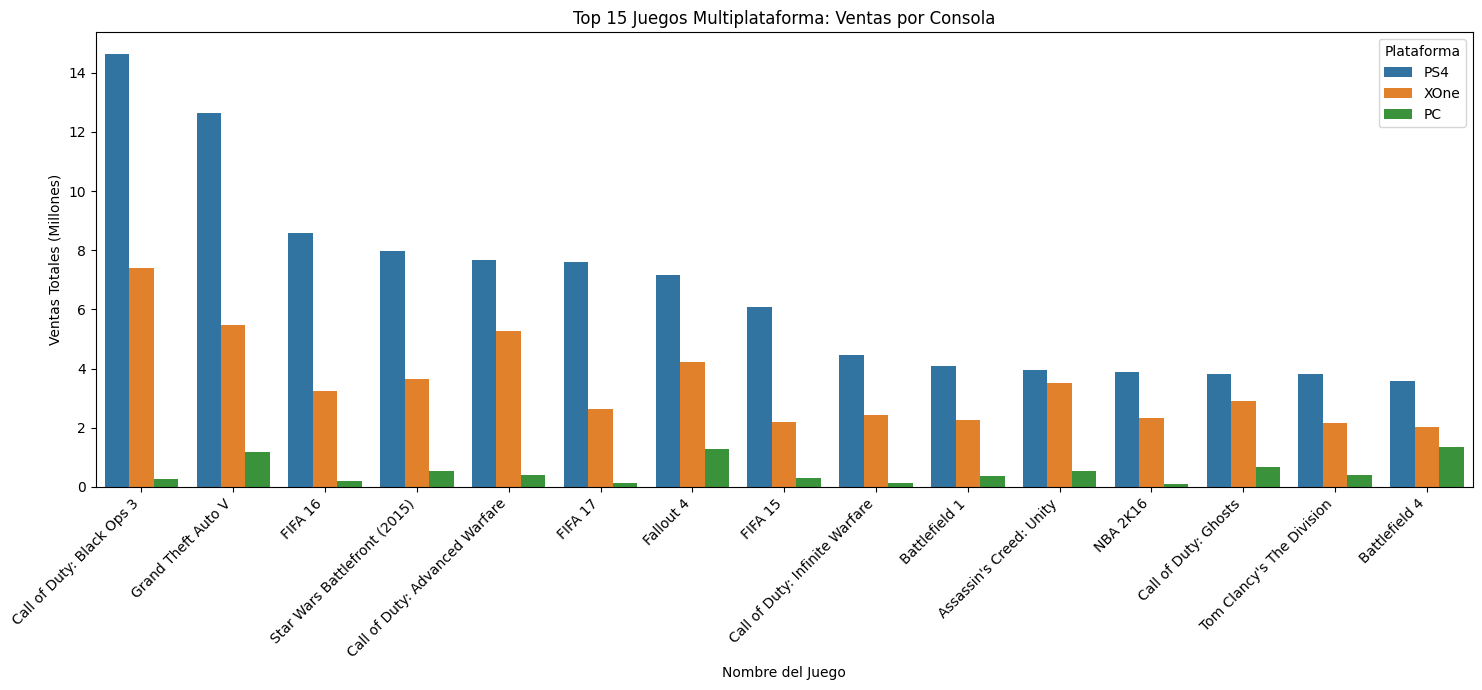

In [25]:
#grafica de comparacion de venta mismos juegos diferentes plataformas 
top_juegos = juegos_en_todas.groupby('name')['total_sales'].sum().sort_values(ascending=False).head(15).index
df_top = juegos_en_todas[juegos_en_todas['name'].isin(top_juegos)]

plt.figure(figsize=(15, 7))
sns.barplot(data=df_top, x='name', y='total_sales', hue='platform')
plt.xticks(rotation=45, ha='right')
plt.title('Top 15 Juegos Multiplataforma: Ventas por Consola')
plt.xlabel('Nombre del Juego')
plt.ylabel('Ventas Totales (Millones)')
plt.legend(title='Plataforma')
plt.tight_layout()
plt.show()

* ya que las plataformas elegidas tienen muchos juegos en comun tomamos el top15 con mayores ventas para tener un grafico mas estructurado 

* Liderazgo de PS4: Es evidente que la PS4 domina casi todos los títulos del gráfico.
*  En la mayoría de los juegos comunes (como Call of Duty o FIFA), las ventas en PS4 duplican o triplican a las de Xbox One y PC.
   Esto se debe a una mayor base de usuarios instalada a nivel mundial.
* Xbox One como Segundo Mercado: La consola de Microsoft mantiene una posición sólida, pero siempre por debajo de Sony.
* El Nicho de PC: las ventas de lanzamientos individuales (especialmente títulos AAA físicos/digitales reportados) suelen ser menores.
  

## DISTRUBUCIONN GENERAL DE JUEGOS POR GENERO

In [26]:
#obtenemos las ventas totales por genero 
genre_sales = data_games_relevant.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
genre_sales

genre
Action          321.87
Shooter         232.98
Sports          150.65
Role-Playing    145.89
Misc             62.82
Platform         42.63
Racing           39.89
Fighting         35.31
Adventure        23.64
Simulation       21.76
Strategy         10.08
Puzzle            3.17
Name: total_sales, dtype: float64

In [27]:
# Calculamos la varianza
varianza_ventas = genre_sales.var()

# Calculamos la desviación estándar
desviacion_estandar_ventas = genre_sales.std()

print(f"Varianza de las ventas totales: {varianza_ventas:.2f}")
print(f"Desviación estándar de las ventas totales: {desviacion_estandar_ventas:.2f}")


Varianza de las ventas totales: 10224.66
Desviación estándar de las ventas totales: 101.12


La Varianza: nos dice tan dispersos están los datos respecto al promedio. Al ser ventas de consolas de distintas generaciones, este número será muy alto porque hay mucha diferencia entre los líderes y los últimos lugares.

Desviación estándar de 101.12 muestra que hay géneros muy exitosos y otros de nicho

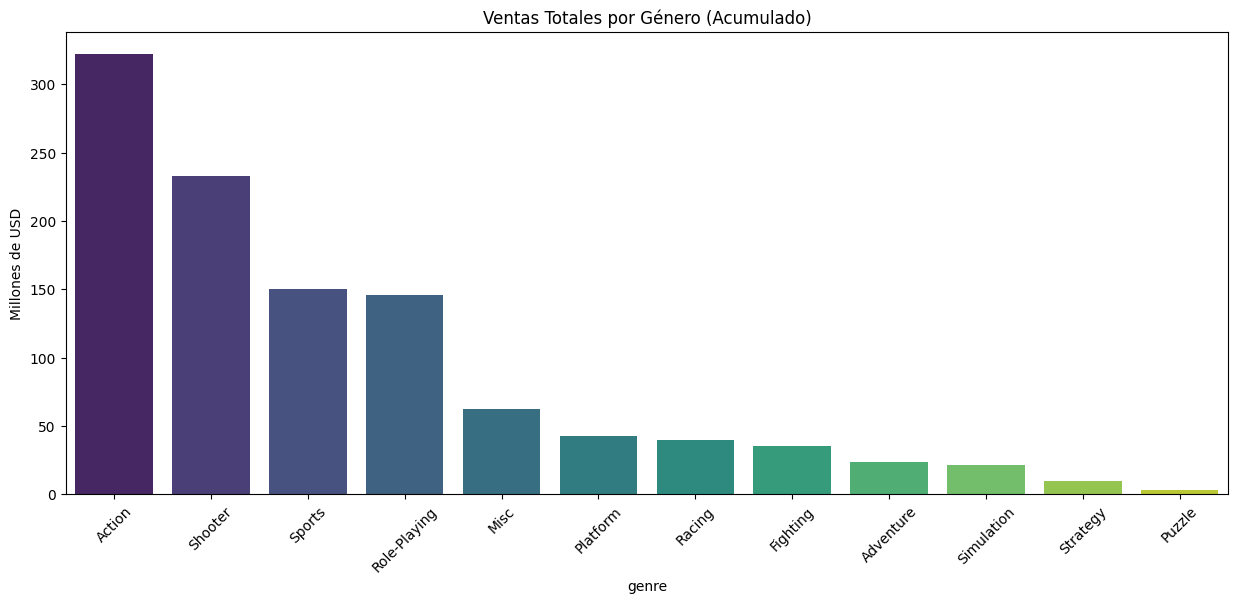

In [28]:
#grafica de ventas de juegos por genero 
plt.figure(figsize=(15, 6))
sns.barplot(x=genre_sales.index, y=genre_sales.values, palette='viridis')
plt.title('Ventas Totales por Género (Acumulado)')
plt.ylabel('Millones de USD')
plt.xticks(rotation=45)
plt.show()


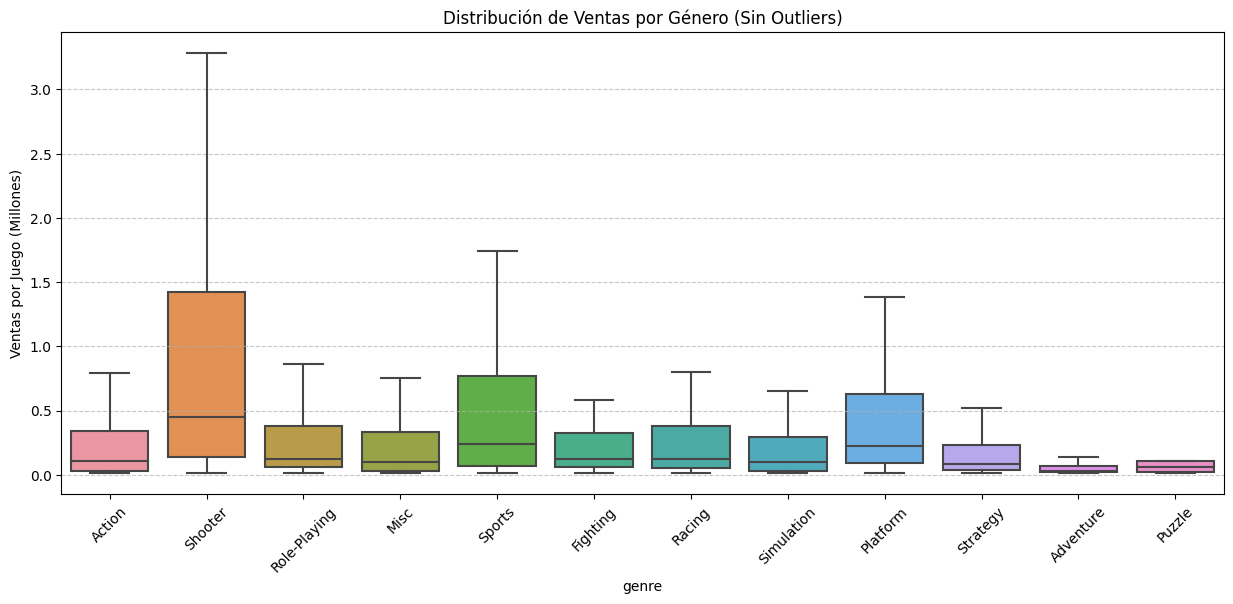

In [36]:
#grafico de caja de distribucion de ventas por genero 
plt.figure(figsize=(15, 6))
sns.boxplot(data=data_games_relevant, x='genre', y='total_sales', showfliers=False)
plt.title('Distribución de Ventas por Género (Sin Outliers)')
plt.ylabel('Ventas por Juego (Millones)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

* Géneros de Ventas Altas (Shooters y Sports):
 Suelen tener la mediana más alta. Esto significa que un juego promedio de disparos tiene más probabilidades de éxito comercial que uno de otro género.
 Son géneros "de masas" con altos presupuestos que generan ingresos constantes en PS4 y Xbox One.
* Géneros de Ventas Bajas (Adventure, Puzzle, Strategy):
  Tienen las ventas totales y medianas más bajas. Son mercados de nicho.
  Aunque haya muchos juegos de estos géneros , el volumen de dinero que mueven es pequeño comparado con la acción.
* El caso del género "Action":
  Suele tener las ventas totales más altas (el bloque más grande), pero una mediana baja.
  Es un género extremadamente competitivo donde unos pocos éxitos masivos se llevan todo el dinero,
  mientras que cientos de otros juegos de acción apenas venden.

# PERFIL DE USUARIO POR REGION 

In [37]:
#establecemos las regiones 
regiones = ['na_sales', 'eu_sales', 'jp_sales']

for region in regiones:
    print(f" Análisis por {region} ")
    # Cinco plataformas principales
    top_platforms = data_games_relevant.groupby('platform')[region].sum().sort_values(ascending=False).head(5)
    print("Top 5 Plataformas:\n", top_platforms)
    # Cinco géneros principales 
    top_genres = data_games_relevant.groupby('genre')[region].sum().sort_values(ascending=False).head(5)
    print("\nTop 5 Géneros:\n", top_genres)
    #Influencia de ESRB
    esrb_impact = data_games_relevant.groupby('rating')[region].sum().sort_values(ascending=False)
    print("\nVentas por clasificación ESRB:\n", esrb_impact)
    print(f"=================")



 Análisis por na_sales 
Top 5 Plataformas:
 platform
PS4     108.74
XOne     93.12
X360     81.66
PS3      63.50
3DS      38.20
Name: na_sales, dtype: float64

Top 5 Géneros:
 genre
Action          126.05
Shooter         109.74
Sports           65.27
Role-Playing     46.40
Misc             27.49
Name: na_sales, dtype: float64

Ventas por clasificación ESRB:
 rating
M          202.57
E           85.11
E10+        74.86
T           74.77
Unknown      0.40
Name: na_sales, dtype: float64
 Análisis por eu_sales 
Top 5 Plataformas:
 platform
PS4     141.09
PS3      67.81
XOne     51.59
X360     42.52
3DS      30.96
Name: eu_sales, dtype: float64

Top 5 Géneros:
 genre
Action          118.13
Shooter          87.86
Sports           60.52
Role-Playing     36.97
Racing           20.19
Name: eu_sales, dtype: float64

Ventas por clasificación ESRB:
 rating
M          179.93
E           92.29
T           61.46
E10+        58.22
Unknown      0.33
Name: eu_sales, dtype: float64
 Análisis por jp_sales

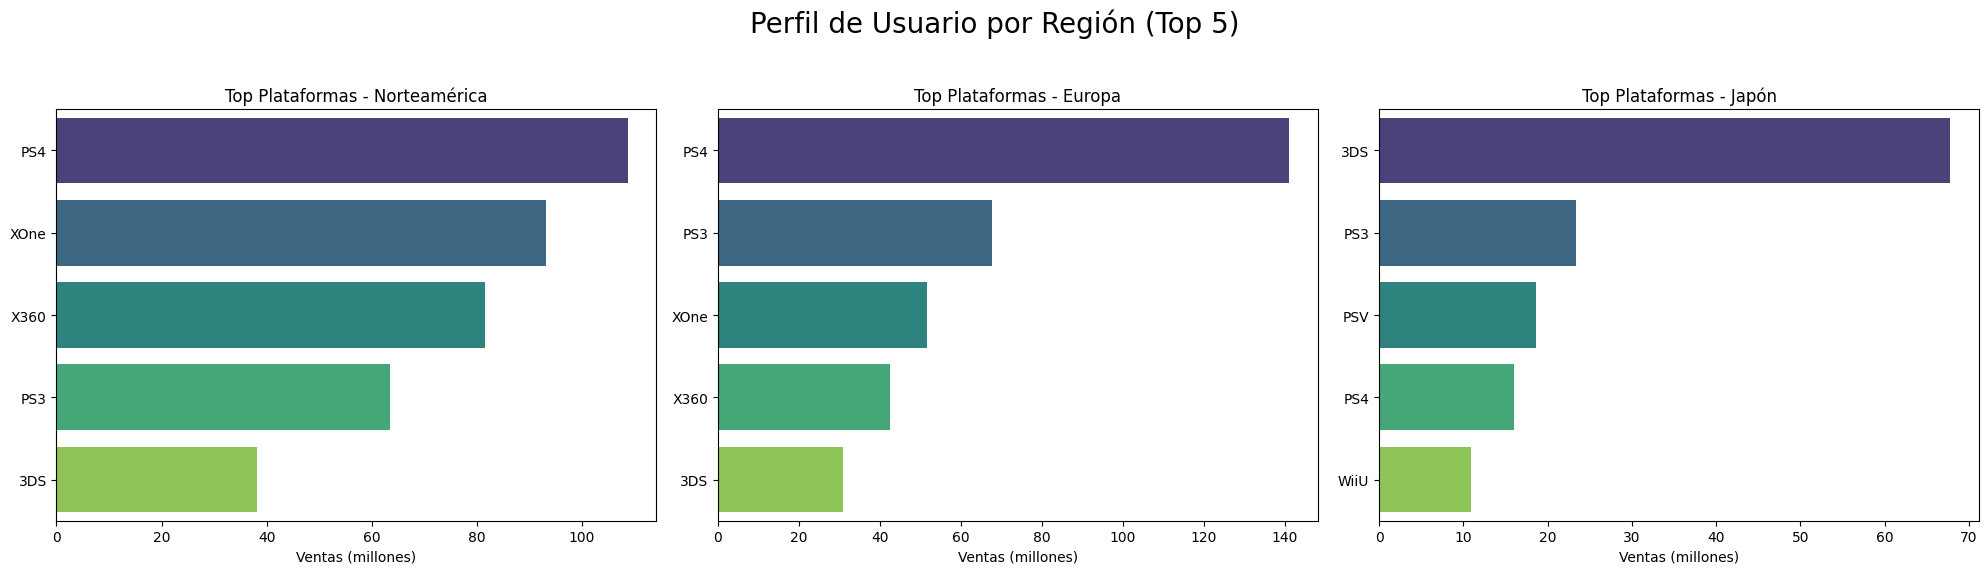

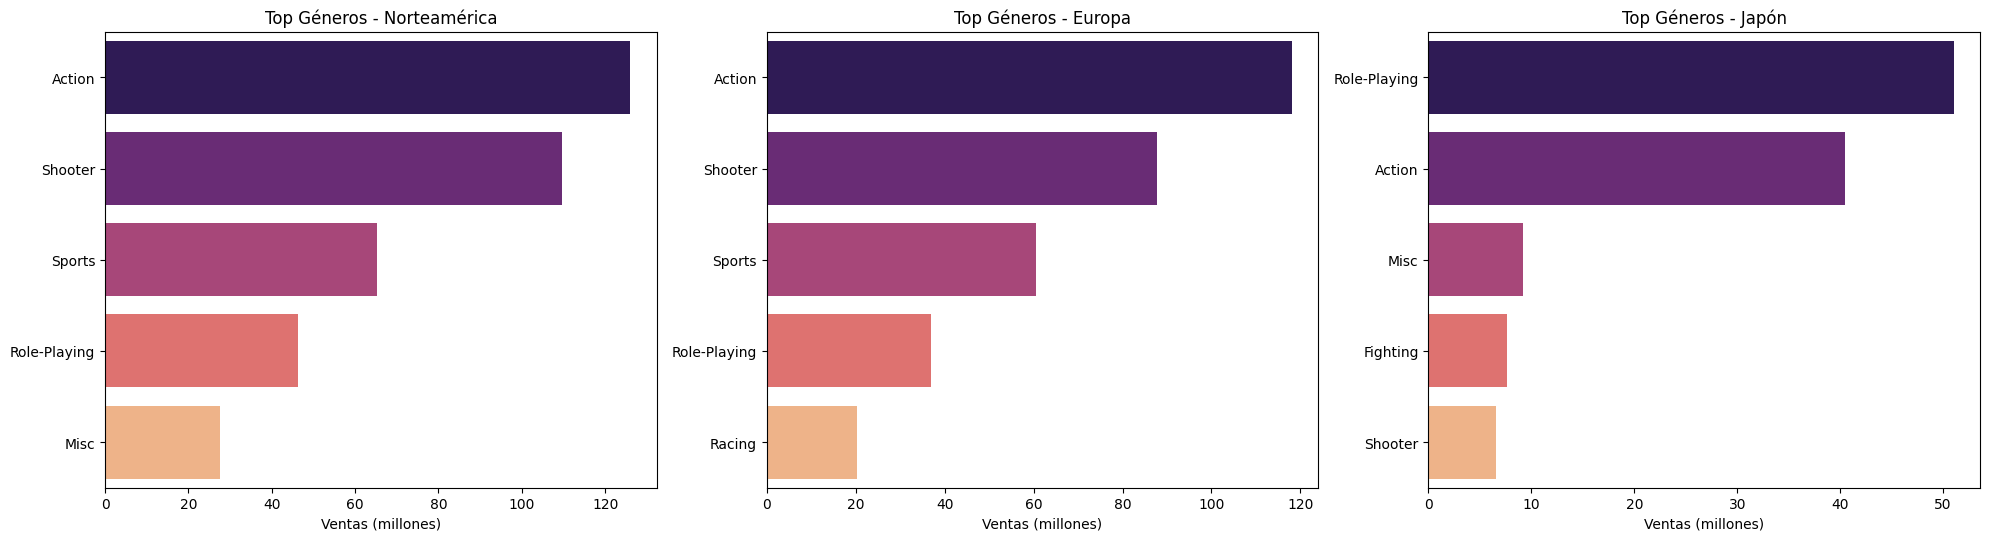

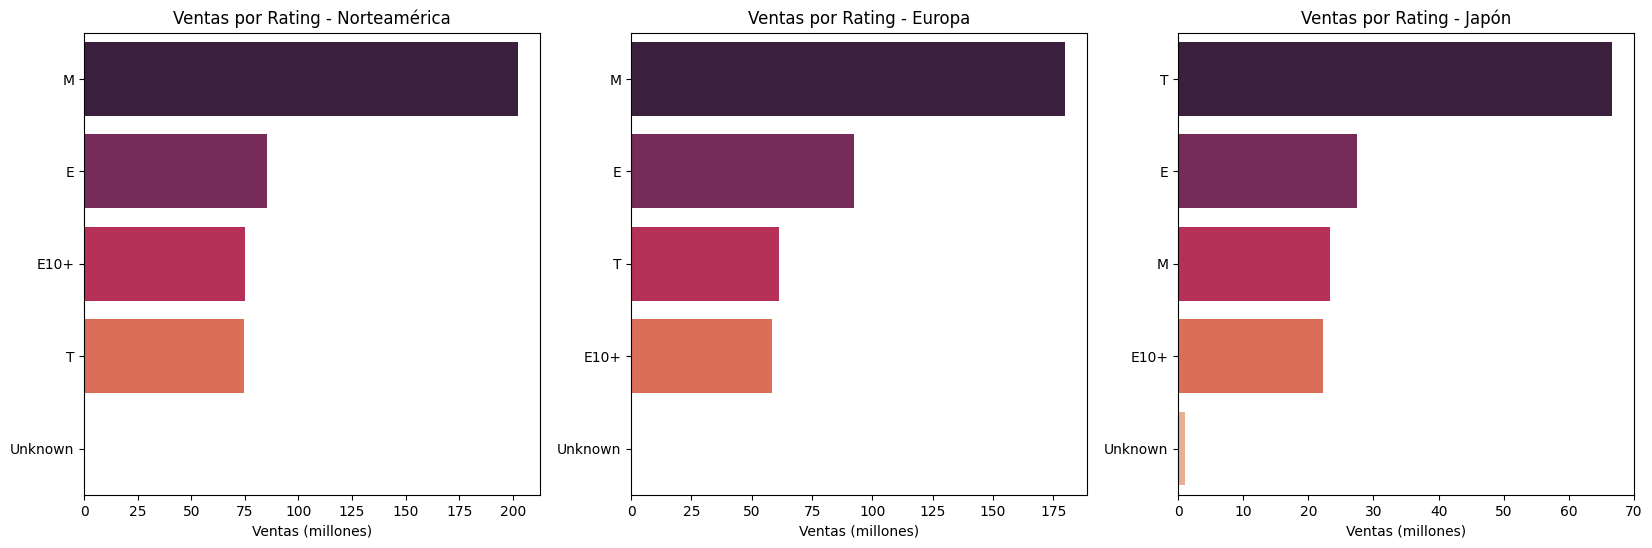

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Perfil de Usuario por Región (Top 5)', fontsize=20)

regiones = ['na_sales', 'eu_sales', 'jp_sales']
titulos = ['Norteamérica', 'Europa', 'Japón']

# Grafica Plataformas Principales
for i, region in enumerate(regiones):
    top_platforms = data_games_relevant.groupby('platform')[region].sum().sort_values(ascending=False).head(5)
    sns.barplot(x=top_platforms.values, y=top_platforms.index, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Top Plataformas - {titulos[i]}')
    axes[i].set_xlabel('Ventas (millones)')
    axes[i].set_ylabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Grafica Géneros Principales
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i, region in enumerate(regiones):
    top_genres = data_games_relevant.groupby('genre')[region].sum().sort_values(ascending=False).head(5)
    sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[i], palette='magma')
    axes[i].set_title(f'Top Géneros - {titulos[i]}')
    axes[i].set_xlabel('Ventas (millones)')
    axes[i].set_ylabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 3. Grafica Impacto de ESRB
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i, region in enumerate(regiones):
    esrb_impact = data_games_relevant.groupby('rating')[region].sum().sort_values(ascending=False)
    sns.barplot(x=esrb_impact.values, y=esrb_impact.index, ax=axes[i], palette='rocket')
    axes[i].set_title(f'Ventas por Rating - {titulos[i]}')
    axes[i].set_xlabel('Ventas (millones)')
    axes[i].set_ylabel('')


plt.show()

Cinco plataformas principales: Variaciones en cuotas de mercado

Existe una diferencia clara en la preferencia de consolas según la región:
* Norteamérica y Europa: Comparten un perfil similar con la PS4 como líder absoluta.
  Sin embargo, en Norteamérica la XOne y la X360 tienen una cuota de mercado mucho más sólida (puestos 2 y 3) comparado con Europa, donde la PS3 mantiene una relevancia mayor.
* Japón: El mercado es distinto. La plataforma líder es la 3DS, una consola portátil, lo cual refleja el estilo de vida japonés. Consolas que son "reinas" en occidente, como la PS4, aquí ocupan el cuarto lugar, y las plataformas de Microsoft (Xbox) ni siquiera aparecen en el Top 5.

Cinco géneros principales: Diferencias culturales
Las preferencias de juego muestran el contraste entre los gustos occidentales y orientales:

* Norteamérica y Europa: Los géneros de Action y Shooter dominan casi por igual, sumando la gran mayoría de las ventas.
* Son mercados que prefieren experiencias cinematográficas y competitivas.
* Japón: Aquí el líder indiscutible es el Role-Playing (RPG). Mientras que en occidente el RPG es el cuarto género, en Japón supera por mucho a la acción. Además, aparecen géneros como Fighting y Misc que tienen más peso que en las otras regiones, mientras que los Shooters apenas alcanzan a entrar en el Top 5 con ventas mínimas.

Impacto de las clasificaciones ESRB en las ventas
La clasificación por edades influye de manera distinta según la región:

* Norteamérica y Europa: El patrón es idéntico. Los juegos con clasificación M (Mature - para adultos) son los que más dinero generan, seguidos por los juegos E (Everyone - para todos). Esto indica que el grueso del gasto en estas regiones proviene de un público adulto que consume títulos intensos o de acción.
* Japón: El panorama cambia . La clasificación más vendida es la T (Teen - para adolescentes), seguida por la E.
  La clasificación M tiene un impacto mucho menor en comparación con occidente.

# PRUEVAS DE HIPOTESIS

Utilizaremos una prueba t de dos muestras independientes para comparar las medias.
Hipótesis 1: Xbox One vs. PC

* H₀ (Nula): Las calificaciones promedio de los usuarios para Xbox One y PC son iguales.
* H₁ (Alternativa): Las calificaciones promedio son diferentes.
* usaremos un umbral apha de 0.05 

In [47]:
# extraccion de datos 
xone_scores = data_games_relevant[(data_games_relevant['platform'] == 'XOne') & (data_games_relevant['user_score'])]['user_score']
pc_scores = data_games_relevant[(data_games_relevant['platform'] == 'PC') & (data_games_relevant['user_score'])]['user_score']
#valor alpha
alpha = 0.05
#prueva de hipotesis
results = st.ttest_ind(xone_scores, pc_scores, equal_var=False)

print(f'Valor p: {results.pvalue}')
if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula.")
else:
    print("No podemos rechazar la hipótesis nula.")

Valor p: 0.06848626908965154
No podemos rechazar la hipótesis nula.


FORMULACION DE LAS HIPOTESIS (Nula y Alternativa)
La formulación se basa en el principio de que la Hipótesis Nula, siempre es el "punto de partida" o la igualdad,
 mientras que la Alternativa es lo que intentamos demostrar.
* Hipótesis Nula : Se establece bajo el supuesto de que no hay diferencia entre los grupos.
 En este caso: "Las calificaciones promedio de los usuarios para Xbox One y PC son iguales"
* Hipótesis Alternativa : Planteamos que existe una diferencia significativa que no se debe al azar.
  En este caso: " Las calificaciones promedio son diferentes".
CRITERIO DE PRUEBA DE HIPOTESIS NULA
El criterio principal es el valor p (p-value) comparado con un nivel de significancia alfa
* Se utilizó la Prueba t de Student para muestras independientes(uasando equal_var=False), Porque estamos comparando las medias de  dos poblaciones distintas (XBOX ONE vs. PC) y no sabemos si sus varianzas son iguales.
* El nivel de significancia Se fijó en 0.05 (5%), ya Es el estándar en la industria y la investigación científica.
* Significa que solo aceptamos un 5% de probabilidad de cometer un "Error"

Hipótesis 2: Géneros Acción vs. Deportes

* H₀: El promedio de calificación de usuarios para Acción y Deportes es el mismo.
* H₁: El promedio es diferente.
* usaremos un umbral apha de 0.05 

In [58]:
# extraccion de datos 
action_scores = data_games_relevant[(data_games_relevant['genre'] == 'Action') & (data_games_relevant['user_score'])]['user_score']
sports_scores = data_games_relevant[(data_games_relevant['genre'] == 'Sports') & (data_games_relevant['user_score'])]['user_score']
#valor alpha
alpha = 0.05 
#prueva de hipotesis
results_genre = st.ttest_ind(action_scores, sports_scores, equal_var=False)
print(f'Valor p: {results_genre.pvalue}')
if results_genre.pvalue < alpha:
    print("Rechazamos la hipótesis nula: Los usuarios califican de forma distinta los juegos de Acción y Deportes.")
else:
    print("No rechazamos la hipótesis nula: No hay evidencia suficiente para decir que las calificaciones son diferentes.")



Valor p: 1.608959959533731e-21
Rechazamos la hipótesis nula: Los usuarios califican de forma distinta los juegos de Acción y Deportes.


formulacion de las hipótesis (Nula y Alternativa)
La formulación se basa en el principio de que la Hipótesis Nula, siempre es el "punto de partida" o la igualdad,
 mientras que la Alternativa es lo que intentamos demostrar.
* Hipótesis Nula : Se establece bajo el supuesto de que no hay diferencia entre los grupos.
 En este caso: "El promedio de calificación de los usuarios para el género Acción es igual al de Deportes"
* Hipótesis Alternativa : Planteamos que existe una diferencia significativa que no se debe al azar.
  En este caso: "El promedio de calificación es diferente".
CRITERIO DE PRUEVA DE HIPOTESIS NULA  
El criterio principal es el valor p (p-value) comparado con un nivel de significancia alfa
* Se utilizó la Prueba t de Student para muestras independientes(uasando equal_var=False), Porque estamos comparando las medias de  dos poblaciones distintas (Acción vs. Deportes) y no sabemos si sus varianzas son iguales.
* El nivel de significancia Se fijó en 0.05 (5%), ya Es el estándar en la industria y la investigación científica.
* Significa que solo aceptamos un 5% de probabilidad de cometer un "Error"    .

# CONCLUSION GENERAL

ANALISIS
* Este análisis se basó en datos de videojuegos del período 2013-2016 para identificar 
patrones y tendencias que permitan hacer proyecciones estratégicas para 2017. 
Se analizaron juegos de  múltiples plataformas, géneros y regiones.

HALLASGOS CLAVE POR CATEGORIA 

* PLATAFORMAS : Las plataformas que dominan el mercado en regiones como NA y EU son ps4, xbox one,ps3 y xbox360y en japon es un mercado completamente distinto siendo 3ds la plataforma dominante 
* GENEROS : Los generos que dominan el mercado en regiones como  NA y EU son action, shooter y esport mientras que japon su mercado esta dominado por role-playing y action
* REGIONES: Encontramos una diferwencia cultural en japon siendo los juegos de rol play la tendencia a diferencia de EU y NA donde los juegos juegos de accion destacan 
*  Factores de Éxito y Recomendaciones:
Para maximizar las ventas en 2017, la estrategia debe diversificarse:

* Para el mercado global: Apostar por lanzamientos en PS4, ya que es la plataforma con mayor inercia de ventas en las regiones más grandes.
* Contenido: Los títulos de Acción con clasificación M son la apuesta más segura en Occidente.
* Para entrar con éxito en Japón, es indispensable contar con un título de Rol (RPG) apto para adolescentes.
* Calificaciones: Aunque las críticas de los usuarios son importantes para la comunidad, las ventas están más fuertemente influenciadas por la plataforma y el género que por el puntaje promedio del usuario.

NOTA SOBRE LOS DATOS RATING:
Se identificó un volumen significativo de valores ausentes en la columna rating, especialmente en títulos de regiones fuera de EE. UU. (como Japón). Estos fueron imputados utilizando la moda por género y plataforma, lo que permitió un análisis más robusto sin perder datos valiosos, aunque se reconoce que el sistema de clasificación ESRB es más relevante para el mercado americano que para el asiático.